<a href="https://colab.research.google.com/github/zixaxa/data-dk/blob/main/SARIMAETS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPOR LIBRARY

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from math import sqrt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_percentage_error,mean_squared_error,mean_absolute_error
import warnings
warnings.simplefilter("ignore")

#EDA & ETL

In [2]:
df = pd.read_excel("https://raw.githubusercontent.com/zixaxa/data-dk/main/data_dispensasi_kawin.xlsx")


In [3]:
df

,No,Nomor Perkara,Klasifikasi Perkara,Para Pihak,Status Perkara,Lama Proses,Link,Tanggal Register
0,625,0916/Pdt.P/2015/PA.Pra,Dispensasi Kawin,Pemohon:,Putusan,21 Hari,[detil],2015-10-23
1,624,0711/Pdt.P/2016/PA.Pra,Dispensasi Kawin,Pemohon:,Putusan,30 Hari,[detil],2016-02-09
2,623,0851/Pdt.P/2016/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,32 Hari,[detil],2016-05-19
3,622,0853/Pdt.P/2016/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,16 Hari,[detil],2016-05-30
4,621,0855/Pdt.P/2016/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,105 Hari,[detil],2016-06-08
...,...,...,...,...,...,...,...,...
620,5,1194/Pdt.P/2023/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,12 Hari,[detil],2023-11-01
621,4,1385/Pdt.P/2023/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,7 Hari,[detil],2023-12-11
622,3,1387/Pdt.P/2023/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,7 Hari,[detil],2023-12-12
623,2,1389/Pdt.P/2023/PA.Pra,Dispensasi Kawin,Pemohon:,Minutasi,8 Hari,[detil],2023-12-14


In [4]:
hapus_kolom = ['No',	'Nomor Perkara','Klasifikasi Perkara', 'Para Pihak','Status Perkara'	,'Lama Proses','Link']
data = df.drop(hapus_kolom, axis=1)

In [5]:
# Buat kolom baru kosong
data['jumlah'] = pd.Series(np.nan, index=df.index)

# Isi nilai kolom baru dengan 1
data['jumlah'].fillna(int(1), inplace=True)


In [6]:
data

,Tanggal Register,jumlah
0,2015-10-23,1.0
1,2016-02-09,1.0
2,2016-05-19,1.0
3,2016-05-30,1.0
4,2016-06-08,1.0
...,...,...
620,2023-11-01,1.0
621,2023-12-11,1.0
622,2023-12-12,1.0
623,2023-12-14,1.0


In [7]:
dx= data.resample('M', on='Tanggal Register').sum()

In [8]:
dx

,jumlah
Tanggal Register,
2015-10-31,1.0
2015-11-30,0.0
2015-12-31,0.0
2016-01-31,0.0
2016-02-29,1.0
...,...
2023-08-31,5.0
2023-09-30,1.0
2023-10-31,4.0


<Axes: xlabel='Tanggal Register'>

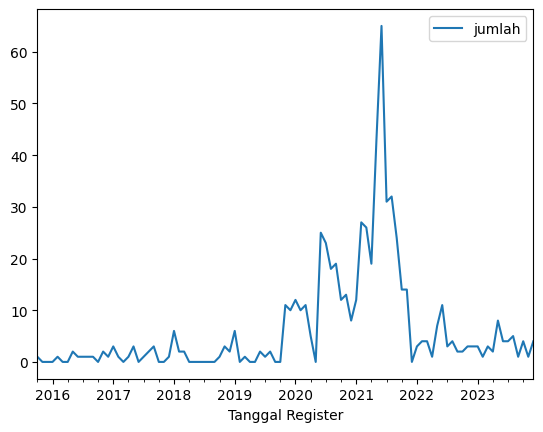

In [9]:
dx.plot()

In [10]:
dx.describe()

,jumlah
count,99.000000
mean,6.313131
std,10.308157
min,0.000000
25%,1.000000
50%,2.000000
75%,7.500000
max,65.000000


#PEMOTONGAN DATA TESTING DAN TRAINING

In [11]:
size = int(len(dx) * 0.90)
train, test = dx[0:size], dx[size:len(dx)]

In [12]:
test

,jumlah
Tanggal Register,
2023-03-31,3.0
2023-04-30,2.0
2023-05-31,8.0
2023-06-30,4.0
2023-07-31,4.0
2023-08-31,5.0
2023-09-30,1.0
2023-10-31,4.0
2023-11-30,1.0


In [13]:
train

,jumlah
Tanggal Register,
2015-10-31,1.0
2015-11-30,0.0
2015-12-31,0.0
2016-01-31,0.0
2016-02-29,1.0
...,...
2022-10-31,2.0
2022-11-30,3.0
2022-12-31,3.0


#KESTASIONERAN


In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [ ]:
def adf_test(series,title=''):
    print(f'Augmented Dickey-Fuller Test :{title}')
    results=adfuller(series.dropna(),autolag='AIC')
    labels=['ADF Test Statistics','P_value']
    out=pd.Series(results[0:2],index=labels)

    for key,val in results[4].items():
        out[f'Critical Value :({key})']=val

    print(out.to_string())

    if results[1]<=0.05:
        print('Data stasioner')
    else:
        print('Data tidak stasioner')

In [ ]:
adf_test(train,"train")

Augmented Dickey-Fuller Test :train
ADF Test Statistics     -2.472835
P_value                  0.122224
Critical Value :(1%)    -3.509736
Critical Value :(5%)    -2.896195
Critical Value :(10%)   -2.585258
Data tidak stasioner


In [ ]:
differencing_1=train.diff().dropna()
seasonal_differencing=train.diff(12).dropna()
double_diff_seasonal=seasonal_differencing.diff(12).dropna()
double_differencing=seasonal_differencing.diff().dropna()

In [ ]:
adf_test(differencing_1,"differencing 1")
adf_test(seasonal_differencing,"seasonal differencing")
adf_test(double_differencing,"double_differencing")
adf_test(double_diff_seasonal,"double differencing seasonal")

Augmented Dickey-Fuller Test :differencing 1
ADF Test Statistics     -5.070655
P_value                  0.000016
Critical Value :(1%)    -3.512738
Critical Value :(5%)    -2.897490
Critical Value :(10%)   -2.585949
Data stasioner
Augmented Dickey-Fuller Test :seasonal differencing
ADF Test Statistics     -2.148388
P_value                  0.225508
Critical Value :(1%)    -3.536928
Critical Value :(5%)    -2.907887
Critical Value :(10%)   -2.591493
Data tidak stasioner
Augmented Dickey-Fuller Test :double_differencing
ADF Test Statistics     -3.525717
P_value                  0.007351
Critical Value :(1%)    -3.538695
Critical Value :(5%)    -2.908645
Critical Value :(10%)   -2.591897
Data stasioner
Augmented Dickey-Fuller Test :double differencing seasonal
ADF Test Statistics     -5.060892
P_value                  0.000017
Critical Value :(1%)    -3.560242
Critical Value :(5%)    -2.917850
Critical Value :(10%)   -2.596796
Data stasioner


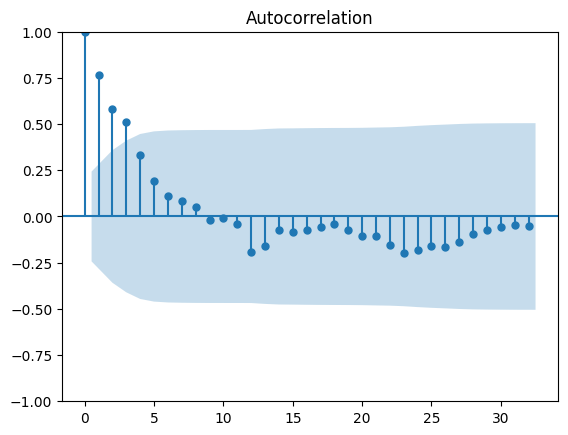

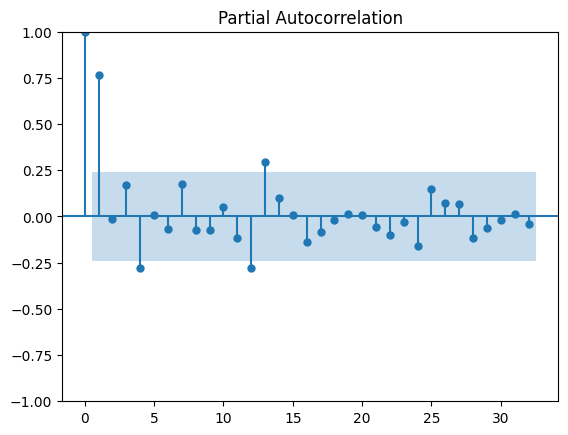

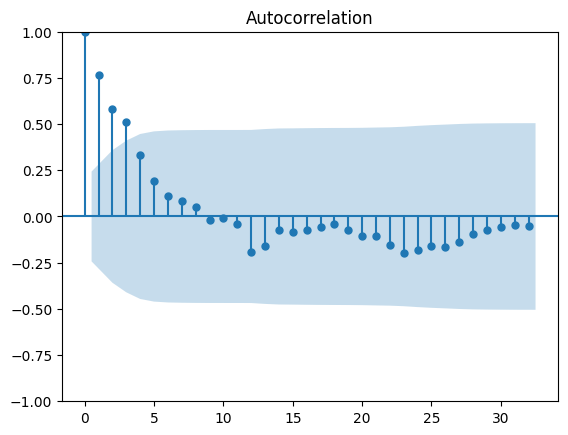

In [ ]:
plot_pacf(double_diff_seasonal,lags=32)
plot_acf(double_diff_seasonal,lags=32)

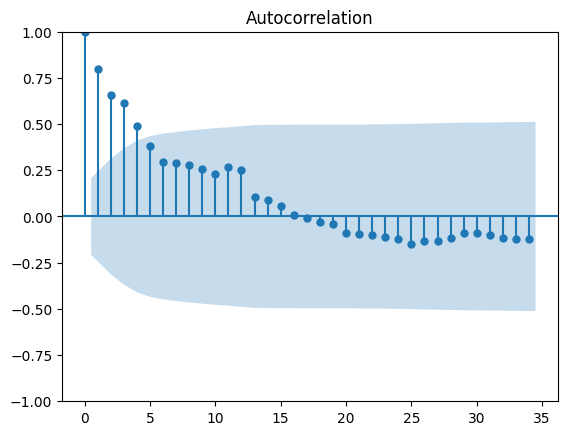

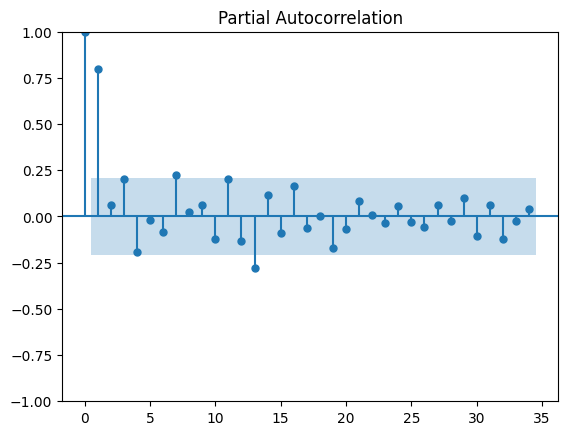

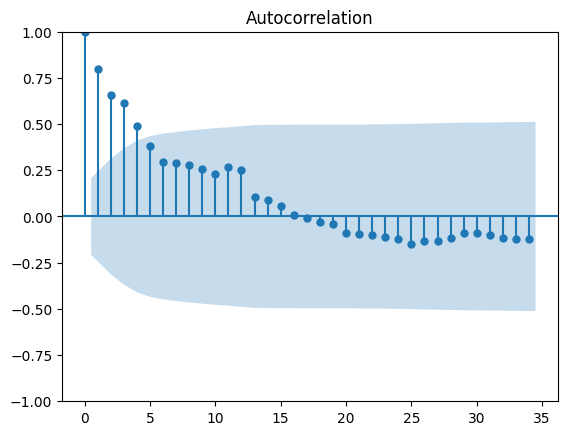

In [ ]:
plot_pacf(train,lags=34)
plot_acf(train,lags=34)

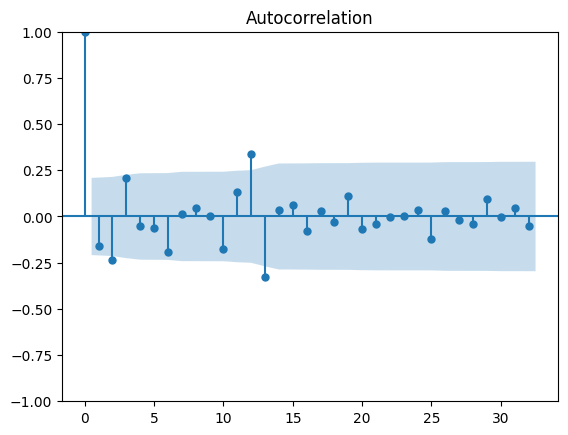

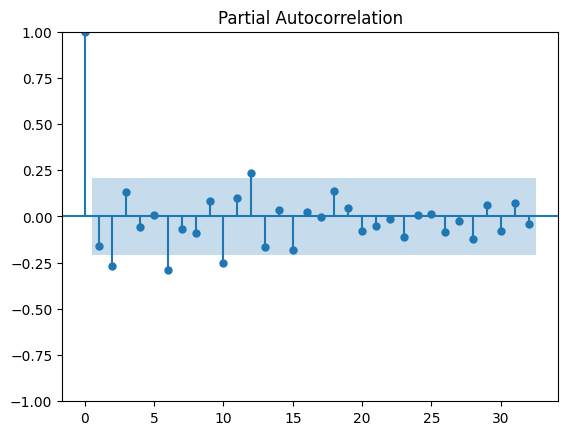

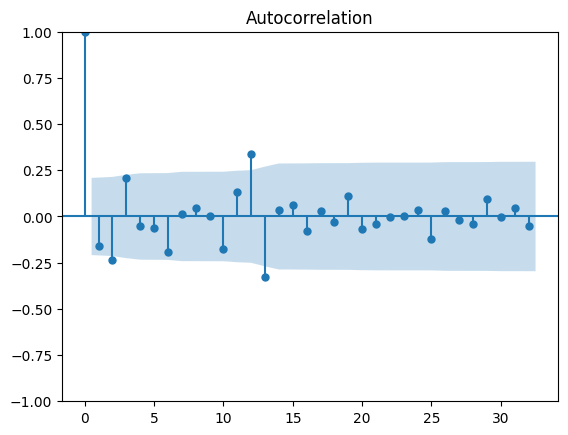

In [ ]:
plot_pacf(differencing_1,lags=32)
plot_acf(differencing_1,lags=32)

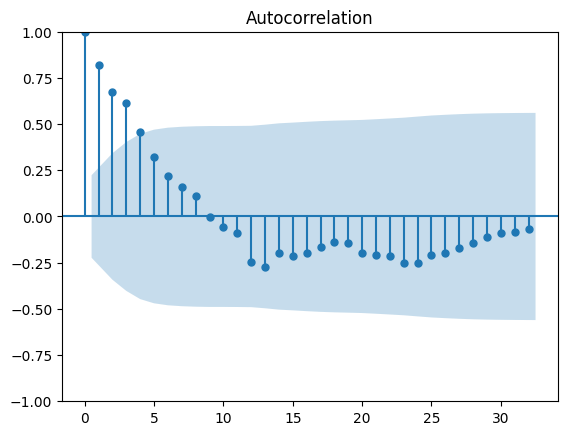

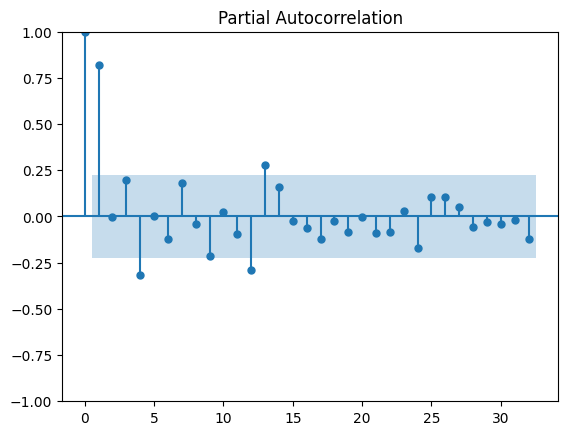

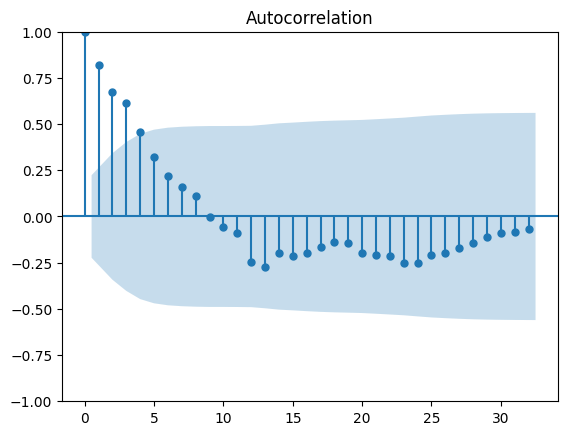

In [ ]:
plot_pacf(seasonal_differencing,lags=32)
plot_acf(seasonal_differencing,lags=32)

#SARIMA

"The seasonal part of an AR or MA model will be seen in the seasonal lags of the PACF and ACF. For example, an ARIMA(0,0,0)(0,0,1)12 model will show:

a spike at lag 12 in the ACF but no other significant spikes;
exponential decay in the seasonal lags of the PACF (i.e., at lags 12, 24, 36, …).
Similarly, an ARIMA(0,0,0)(1,0,0) 12
model will show:
exponential decay in the seasonal lags of the ACF;
a single significant spike at lag 12 in the PACF."

>
**Forecasting: Principles and Practice (3rd ed)
Rob J Hyndman and George Athanasopoulos
Monash University, Australia**






In [14]:
def pdq_grid(p, d, q):
    pdq = []
    for i in p:
        for j in d:
            for k in q:
                pdq.append([i, j, k])
    return pdq

def PDQm_grid(P, D, Q, m):
    PDQm = []
    for i in P:
        for j in D:
            for k in Q:
                for l in m:
                    PDQm.append([i, j, k, l])
    return PDQm

In [38]:
#kemungkinan pdq PDQM berdasarkan pacf dan acf
p = [0,1,2,3,4,6,7,9,10]
d = [0,1,2]
q = [0,1,2,3,4,6,10,11]
P = [0,1]
D = [0, 1,2]
Q = [0,1]
m = [12]
pdq = pdq_grid(p, d, q)
PDQm = PDQm_grid(P, D, Q, m)

In [ ]:

def SARIMA_grid(train, order, seasonal_order):


    model_info = []


    import warnings
    warnings.simplefilter("ignore")


    for i in order:
        for j in seasonal_order:
            try:
                model = SARIMAX(train, order=i, seasonal_order=j,enforce_stationarity=False, enforce_invertibility=False)

                result = model.fit()
                predictions = result.predict(start=size, end=len(dx) - 1)



                MAPE = mean_absolute_percentage_error(test,predictions)
                RMSE = sqrt(mean_squared_error(test,predictions))
                AIC = result.aic
                BIC = result.bic


                info = [i, j, MAPE, RMSE, AIC, BIC]
                model_info.append(info)

            except:
                continue


    columns = ["order", "seasonal_order", "MAPE", "RMSE", "AIC", "BIC"]
    model_info = pd.DataFrame(data=model_info, columns=columns)
    return model_info

In [ ]:

model_info = SARIMA_grid(train, order=pdq, seasonal_order=PDQm)

In [ ]:

mape_terkecil = model_info.nsmallest(10, "MAPE")
mape_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
1459,"[6, 0, 1]","[1, 0, 1, 12]",0.394991,2.377891,484.241113,506.867912
1471,"[6, 0, 2]","[1, 0, 1, 12]",0.397030,2.380000,486.238815,511.128293
1447,"[6, 0, 0]","[1, 0, 1, 12]",0.397818,2.308584,483.653361,504.017480
1470,"[6, 0, 2]","[1, 0, 0, 12]",0.402724,2.236414,484.266221,506.893020
1458,"[6, 0, 1]","[1, 0, 0, 12]",0.403154,2.236020,482.267857,502.631976
1158,"[4, 0, 0]","[1, 0, 0, 12]",0.423097,2.474318,489.396992,503.139749
1002,"[3, 1, 3]","[1, 0, 0, 12]",0.429566,2.368295,495.216518,513.540194
1122,"[3, 2, 6]","[1, 0, 0, 12]",0.431480,2.256387,497.437603,522.480930
1446,"[6, 0, 0]","[1, 0, 0, 12]",0.432341,2.202416,481.674748,499.776187
1123,"[3, 2, 6]","[1, 0, 1, 12]",0.434268,2.251030,476.204996,502.839088


In [ ]:

rmse_terkecil = model_info.nsmallest(10, "RMSE")
rmse_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
456,"[1, 1, 10]","[0, 0, 0, 12]",0.569270,1.709398,526.903710,555.029375
564,"[1, 2, 11]","[0, 0, 0, 12]",0.688800,1.917102,522.484417,552.611762
654,"[2, 0, 10]","[1, 0, 0, 12]",0.623120,1.918124,511.563908,544.008741
774,"[2, 2, 0]","[1, 0, 0, 12]",0.578572,2.028097,511.378618,520.540456
775,"[2, 2, 0]","[1, 0, 1, 12]",0.691331,2.031563,513.363563,524.815861
276,"[0, 2, 11]","[0, 0, 0, 12]",0.939913,2.105260,520.515889,548.325747
396,"[1, 1, 1]","[0, 0, 0, 12]",0.691350,2.127370,576.402996,583.766038
1884,"[7, 1, 6]","[0, 0, 0, 12]",0.559254,2.135620,550.898741,584.421029
1674,"[6, 2, 3]","[1, 0, 0, 12]",0.497385,2.155171,482.112595,506.687767
139,"[0, 1, 3]","[1, 0, 1, 12]",0.467863,2.158995,487.341579,501.001576


In [ ]:

aic_terkecil = model_info.nsmallest(10, "AIC")
aic_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
863,"[2, 2, 11]","[1, 2, 1, 12]",11.939072,30.771381,316.849182,343.466169
1151,"[3, 2, 11]","[1, 2, 1, 12]",5.848093,18.323639,319.476582,347.757130
1727,"[6, 2, 11]","[1, 2, 1, 12]",6.450656,19.380629,319.542489,352.813722
1439,"[4, 2, 11]","[1, 2, 1, 12]",8.331073,22.872772,319.744701,349.688810
1721,"[6, 2, 11]","[0, 2, 1, 12]",6.108235,19.119625,320.616969,352.224640
857,"[2, 2, 11]","[0, 2, 1, 12]",7.164564,19.329300,320.776232,345.729657
1145,"[3, 2, 11]","[0, 2, 1, 12]",16.928841,42.146654,321.039947,347.656934
2297,"[9, 2, 11]","[0, 2, 1, 12]",4.301192,14.953563,321.495335,358.093691
2015,"[7, 2, 11]","[1, 2, 1, 12]",6.331100,18.975635,321.696903,356.631697
281,"[0, 2, 11]","[0, 2, 1, 12]",8.290470,20.287066,322.138321,343.764622


In [ ]:

bic_terkecil = model_info.nsmallest(10, "BIC")
bic_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
863,"[2, 2, 11]","[1, 2, 1, 12]",11.939072,30.771381,316.849182,343.466169
281,"[0, 2, 11]","[0, 2, 1, 12]",8.290470,20.287066,322.138321,343.764622
857,"[2, 2, 11]","[0, 2, 1, 12]",7.164564,19.329300,320.776232,345.729657
287,"[0, 2, 11]","[1, 2, 1, 12]",8.413969,21.708401,322.485148,345.775011
191,"[0, 1, 11]","[1, 2, 1, 12]",4.167633,13.601831,323.548878,347.193190
1145,"[3, 2, 11]","[0, 2, 1, 12]",16.928841,42.146654,321.039947,347.656934
1151,"[3, 2, 11]","[1, 2, 1, 12]",5.848093,18.323639,319.476582,347.757130
575,"[1, 2, 11]","[1, 2, 1, 12]",16.665691,42.287834,322.918598,347.872023
185,"[0, 1, 11]","[0, 2, 1, 12]",4.849808,14.104472,326.508537,348.463970
761,"[2, 1, 11]","[0, 2, 1, 12]",6.081974,18.040388,323.882218,349.215410


In [ ]:
mape_terbaik = model_info[model_info.MAPE == model_info.MAPE.min()]
rmse_terbaik = model_info[model_info.RMSE == model_info.RMSE.min()]
aic_terbaik = model_info[model_info.AIC == model_info.AIC.min()]
bic_terbaik = model_info[model_info.BIC == model_info.BIC.min()]
pd.concat((mape_terbaik,rmse_terbaik,aic_terbaik,bic_terbaik))

,order,seasonal_order,MAPE,RMSE,AIC,BIC
1459,"[6, 0, 1]","[1, 0, 1, 12]",0.394991,2.377891,484.241113,506.867912
456,"[1, 1, 10]","[0, 0, 0, 12]",0.569270,1.709398,526.903710,555.029375
863,"[2, 2, 11]","[1, 2, 1, 12]",11.939072,30.771381,316.849182,343.466169
863,"[2, 2, 11]","[1, 2, 1, 12]",11.939072,30.771381,316.849182,343.466169


In [ ]:

# Evaluasi
# Here, we use the entire test set for prediction length
model_mape=SARIMAX(train, order=(6,0,1), seasonal_order=(1,0,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_mape= model_mape.fit()
prediksi_model_mape = fit_model_mape.predict(start=size, end=len(dx) - 1)

model_rmse=SARIMAX(train, order=(1,1,10), seasonal_order=(0,0,0,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_rmse= model_rmse.fit()
prediksi_model_rmse = fit_model_rmse.predict(start=size, end=len(dx) - 1)

model_aic=SARIMAX(train, order=(2,2,11), seasonal_order=(1,2,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_aic= model_aic.fit()
prediksi_model_aic = fit_model_aic.predict(start=size, end=len(dx) - 1)

model_bic=SARIMAX(train, order=(2,2,11), seasonal_order=(2,1,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_bic= model_bic.fit()
prediksi_model_bic = fit_model_bic.predict(start=size, end=len(dx) - 1)

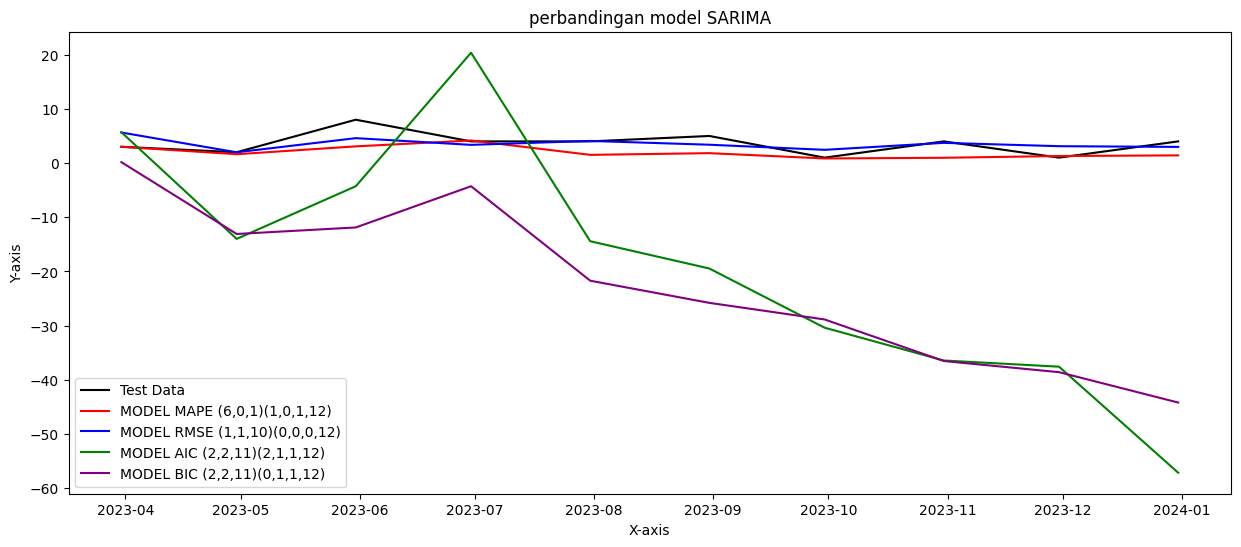

In [ ]:

plt.figure(figsize=(15, 6))

plt.plot(test,color="black", label='Test Data')
plt.plot(prediksi_model_mape, color='red', label='MODEL MAPE (6,0,1)(1,0,1,12)')
plt.plot(prediksi_model_rmse, color='blue', label='MODEL RMSE (1,1,10)(0,0,0,12)')
plt.plot(prediksi_model_aic, color='green', label='MODEL AIC (2,2,11)(2,1,1,12)')
plt.plot(prediksi_model_bic, color='purple', label='MODEL BIC (2,2,11)(0,1,1,12)')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('perbandingan model SARIMA')

# Add legend
plt.legend()

# Display the plot
plt.show()

In [ ]:
model_info.to_excel("hasil_sarima.xlsx")

#EKSPONENTIAL SMOOTHING

In [ ]:
tahun=train["jumlah"].iloc[:24]

x = tahun.iloc[:12].tolist()
y = tahun.iloc[12:].tolist()

print(x)
print(y)

[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 2.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 2.0, 1.0, 3.0, 1.0, 0.0, 1.0, 3.0, 0.0, 1.0, 2.0, 3.0]


In [ ]:
il = np.mean(x)
print("Initial Level: ",il)

Initial Level:  0.6666666666666666


In [ ]:
perbedaan = [y - x for x, y in zip(x, y)]
print("perbedaan : ",perbedaan)
it =(sum(perbedaan) / len(perbedaan))/len(perbedaan)
print("Initial Trend: ",it)

perbedaan :  [-1.0, 2.0, 1.0, 3.0, 0.0, 0.0, 1.0, 1.0, -1.0, 0.0, 1.0, 2.0]
Initial Trend:  0.0625


In [ ]:
ise= x/il
print(ise)

[1.5 0.  0.  0.  1.5 0.  0.  3.  1.5 1.5 1.5 1.5]


In [ ]:
model_hw = ExponentialSmoothing(
    train,
    seasonal_periods=12,
    trend="add",
    seasonal="add",
    initialization_method="known",initial_level=il,initial_trend=it,initial_seasonal=ise
)

In [ ]:
import itertools

In [ ]:
alphas = betas = gammas = phi = np.arange(0,1, 0.1)
abgp = list(itertools.product(alphas, betas, gammas,phi))

In [ ]:
def tes_optimizer(train, abgp, step=len(test)):
    model_hw = []
    for comb in abgp:
        model_acak = ExponentialSmoothing(train, trend="add", seasonal="add", damped_trend=True,freq='M',seasonal_periods=12,initialization_method="known",initial_level=il,initial_trend=it,initial_seasonal=ise).\
            fit(smoothing_level=comb[0], smoothing_trend=comb[1], smoothing_seasonal=comb[2],damping_trend=comb[3])

        y_pred = model_acak.forecast(step)
        MAPE = mean_absolute_percentage_error(test, y_pred)
        RMSE = sqrt(mean_squared_error(test,y_pred))
        AIC = model_acak.aic
        BIC = model_acak.bic
        info = [comb[0],comb[1],comb[2],comb[3], MAPE, RMSE, AIC, BIC]
        model_hw.append(info)



    columns = ["alpha","beta","gamma","phi", "MAPE", "RMSE", "AIC", "BIC"]
    model_hw = pd.DataFrame(data=model_hw, columns=columns)

    return model_hw

In [ ]:
model_hw = tes_optimizer(train,abgp)

In [ ]:
mape_hw = model_hw.nsmallest(10, "MAPE")
mape_hw

,alpha,beta,gamma,phi,MAPE,RMSE,AIC,BIC
1208,0.1,0.2,0.0,0.8,0.469707,1.627466,417.526066,459.832884
2708,0.2,0.7,0.0,0.8,0.475600,1.708758,402.787148,445.093966
1109,0.1,0.1,0.0,0.9,0.480254,1.783692,422.733332,465.040150
3409,0.3,0.4,0.0,0.9,0.486921,1.756811,399.697822,442.004641
2709,0.2,0.7,0.0,0.9,0.493898,1.493953,418.437541,460.744360
2907,0.2,0.9,0.0,0.7,0.504595,1.986026,394.709736,437.016554
2807,0.2,0.8,0.0,0.7,0.506499,1.885552,394.809358,437.116176
1407,0.1,0.4,0.0,0.7,0.510866,1.565931,413.180672,455.487491
1507,0.1,0.5,0.0,0.7,0.511323,1.798952,411.602048,453.908867
2707,0.2,0.7,0.0,0.7,0.514502,1.817519,394.911298,437.218116


In [ ]:
rmse_hw = model_hw.nsmallest(10, "RMSE")
rmse_hw

,alpha,beta,gamma,phi,MAPE,RMSE,AIC,BIC
1307,0.1,0.3,0.0,0.7,0.577347,1.428543,415.115279,457.422097
1905,0.1,0.9,0.0,0.5,0.587472,1.446894,408.712507,451.019325
1606,0.1,0.6,0.0,0.6,0.558824,1.450449,410.821812,453.128631
1506,0.1,0.5,0.0,0.6,0.621208,1.453346,412.372902,454.679721
2104,0.2,0.1,0.0,0.4,0.579842,1.456730,399.508851,441.815670
2202,0.2,0.2,0.0,0.2,0.596108,1.456762,399.624748,441.931567
2501,0.2,0.5,0.0,0.1,0.593278,1.456767,399.364209,441.671028
2103,0.2,0.1,0.0,0.3,0.600140,1.456972,399.921314,442.228132
2601,0.2,0.6,0.0,0.1,0.585579,1.456977,399.041967,441.348786
2401,0.2,0.4,0.0,0.1,0.601218,1.457319,399.690288,441.997106


In [ ]:
aic_hw = model_hw.nsmallest(10, "AIC")
aic_hw

,alpha,beta,gamma,phi,MAPE,RMSE,AIC,BIC
9037,0.9,0.0,0.3,0.7,2.561964,7.430112,354.798684,397.105502
9036,0.9,0.0,0.3,0.6,2.562435,7.431089,354.798901,397.105719
9038,0.9,0.0,0.3,0.8,2.561477,7.429169,354.799064,397.105883
9035,0.9,0.0,0.3,0.5,2.562823,7.431934,354.799481,397.106299
9039,0.9,0.0,0.3,0.9,2.561075,7.428479,354.799808,397.106626
9034,0.9,0.0,0.3,0.4,2.563110,7.432585,354.800214,397.107033
9033,0.9,0.0,0.3,0.3,2.563307,7.433046,354.800980,397.107798
9032,0.9,0.0,0.3,0.2,2.563430,7.433352,354.801716,397.108534
9031,0.9,0.0,0.3,0.1,2.563501,7.433539,354.802388,397.109207
9030,0.9,0.0,0.3,0.0,2.563533,7.433643,354.802986,397.109804


In [ ]:
bic_hw = model_hw.nsmallest(10, "BIC")
bic_hw

,alpha,beta,gamma,phi,MAPE,RMSE,AIC,BIC
9037,0.9,0.0,0.3,0.7,2.561964,7.430112,354.798684,397.105502
9036,0.9,0.0,0.3,0.6,2.562435,7.431089,354.798901,397.105719
9038,0.9,0.0,0.3,0.8,2.561477,7.429169,354.799064,397.105883
9035,0.9,0.0,0.3,0.5,2.562823,7.431934,354.799481,397.106299
9039,0.9,0.0,0.3,0.9,2.561075,7.428479,354.799808,397.106626
9034,0.9,0.0,0.3,0.4,2.563110,7.432585,354.800214,397.107033
9033,0.9,0.0,0.3,0.3,2.563307,7.433046,354.800980,397.107798
9032,0.9,0.0,0.3,0.2,2.563430,7.433352,354.801716,397.108534
9031,0.9,0.0,0.3,0.1,2.563501,7.433539,354.802388,397.109207
9030,0.9,0.0,0.3,0.0,2.563533,7.433643,354.802986,397.109804


In [ ]:
mape_terbagus = model_hw[model_hw.MAPE == model_hw.MAPE.min()]
rmse_terbagus = model_hw[model_hw.RMSE == model_hw.RMSE.min()]
aic_terbagus= model_hw[model_hw.AIC == model_hw.AIC.min()]
bic_terbagus = model_hw[model_hw.BIC == model_info.BIC.min()]
pd.concat((mape_terbagus,rmse_terbagus,aic_terbagus,bic_terbagus))

,alpha,beta,gamma,phi,MAPE,RMSE,AIC,BIC
1208,0.1,0.2,0.0,0.8,0.469707,1.627466,417.526066,459.832884
1307,0.1,0.3,0.0,0.7,0.577347,1.428543,415.115279,457.422097
9037,0.9,0.0,0.3,0.7,2.561964,7.430112,354.798684,397.105502


In [ ]:
model_hw.to_excel("hasil_hw.xlsx")

#SARIMA GRID

In [14]:
#kemungkinan pdq PDQM berdasarkan pacf dan acf
p = [0,1,2,3,4,6,7,9,10]
d = [0,1,2]
q = [0,1,2,3,4,6,10,11]
P = [0,1]
D = [0, 1,2]
Q = [0,1]
m = [12]

In [15]:
# Generate all different combinations of p, q and q triplets
pdq = list(itertools.product(p, d, q))

# You'll want to change this according to your time series' frequency
PDQS = [(z[0], z[1], z[2], 12) for z in list(itertools.product(P,D,Q))]

In [16]:
def sarimax_gridsearch(train):

    model_info = []
    for comb in pdq:
        for combs in PDQS:
                model = SARIMAX(train, order=comb, seasonal_order=combs,enforce_stationarity=False, enforce_invertibility=False, freq='M')

                result = model.fit()
                predictions = result.predict(start=size, end=len(dx) - 1)



                MAPE = mean_absolute_percentage_error(test,predictions)
                RMSE = sqrt(mean_squared_error(test,predictions))
                AIC = result.aic
                BIC = result.bic


                baris = [comb,combs, MAPE, RMSE, AIC, BIC]
                model_info.append(baris)


    columns = ["order", "seasonal_order", "MAPE", "RMSE", "AIC", "BIC"]
    model_info = pd.DataFrame(data=model_info, columns=columns)
    return model_info

In [19]:
model_info = sarimax_gridsearch(train)

In [21]:
mape_terkecil = model_info.nsmallest(10, "MAPE")
mape_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
1459,"(6, 0, 1)","(1, 0, 1, 12)",0.394991,2.377891,484.241113,506.867912
1471,"(6, 0, 2)","(1, 0, 1, 12)",0.397030,2.380000,486.238815,511.128293
1447,"(6, 0, 0)","(1, 0, 1, 12)",0.397818,2.308584,483.653361,504.017480
1470,"(6, 0, 2)","(1, 0, 0, 12)",0.402724,2.236414,484.266221,506.893020
1458,"(6, 0, 1)","(1, 0, 0, 12)",0.403154,2.236020,482.267857,502.631976
1158,"(4, 0, 0)","(1, 0, 0, 12)",0.423097,2.474318,489.396992,503.139749
1002,"(3, 1, 3)","(1, 0, 0, 12)",0.429566,2.368295,495.216518,513.540194
1122,"(3, 2, 6)","(1, 0, 0, 12)",0.431480,2.256387,497.437603,522.480930
1446,"(6, 0, 0)","(1, 0, 0, 12)",0.432341,2.202416,481.674748,499.776187
1123,"(3, 2, 6)","(1, 0, 1, 12)",0.434268,2.251030,476.204996,502.839088


In [22]:

rmse_terkecil = model_info.nsmallest(10, "RMSE")
rmse_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
456,"(1, 1, 10)","(0, 0, 0, 12)",0.569270,1.709398,526.903710,555.029375
564,"(1, 2, 11)","(0, 0, 0, 12)",0.688800,1.917102,522.484417,552.611762
654,"(2, 0, 10)","(1, 0, 0, 12)",0.623120,1.918124,511.563908,544.008741
774,"(2, 2, 0)","(1, 0, 0, 12)",0.578572,2.028097,511.378618,520.540456
775,"(2, 2, 0)","(1, 0, 1, 12)",0.691331,2.031563,513.363563,524.815861
276,"(0, 2, 11)","(0, 0, 0, 12)",0.939913,2.105260,520.515889,548.325747
396,"(1, 1, 1)","(0, 0, 0, 12)",0.691350,2.127370,576.402996,583.766038
1884,"(7, 1, 6)","(0, 0, 0, 12)",0.559254,2.135620,550.898741,584.421029
1674,"(6, 2, 3)","(1, 0, 0, 12)",0.497385,2.155171,482.112595,506.687767
139,"(0, 1, 3)","(1, 0, 1, 12)",0.467863,2.158995,487.341579,501.001576


In [23]:
aic_terkecil = model_info.nsmallest(10, "AIC")
aic_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
863,"(2, 2, 11)","(1, 2, 1, 12)",11.939072,30.771381,316.849182,343.466169
1151,"(3, 2, 11)","(1, 2, 1, 12)",5.848093,18.323639,319.476582,347.757130
1727,"(6, 2, 11)","(1, 2, 1, 12)",6.450656,19.380629,319.542489,352.813722
1439,"(4, 2, 11)","(1, 2, 1, 12)",8.331073,22.872772,319.744701,349.688810
1721,"(6, 2, 11)","(0, 2, 1, 12)",6.108235,19.119625,320.616969,352.224640
857,"(2, 2, 11)","(0, 2, 1, 12)",7.164564,19.329300,320.776232,345.729657
1145,"(3, 2, 11)","(0, 2, 1, 12)",16.928841,42.146654,321.039947,347.656934
2297,"(9, 2, 11)","(0, 2, 1, 12)",4.301192,14.953563,321.495335,358.093691
2015,"(7, 2, 11)","(1, 2, 1, 12)",6.331100,18.975635,321.696903,356.631697
281,"(0, 2, 11)","(0, 2, 1, 12)",8.290470,20.287066,322.138321,343.764622


In [24]:
bic_terkecil = model_info.nsmallest(10, "BIC")
bic_terkecil

,order,seasonal_order,MAPE,RMSE,AIC,BIC
863,"(2, 2, 11)","(1, 2, 1, 12)",11.939072,30.771381,316.849182,343.466169
281,"(0, 2, 11)","(0, 2, 1, 12)",8.290470,20.287066,322.138321,343.764622
857,"(2, 2, 11)","(0, 2, 1, 12)",7.164564,19.329300,320.776232,345.729657
287,"(0, 2, 11)","(1, 2, 1, 12)",8.413969,21.708401,322.485148,345.775011
191,"(0, 1, 11)","(1, 2, 1, 12)",4.167633,13.601831,323.548878,347.193190
1145,"(3, 2, 11)","(0, 2, 1, 12)",16.928841,42.146654,321.039947,347.656934
1151,"(3, 2, 11)","(1, 2, 1, 12)",5.848093,18.323639,319.476582,347.757130
575,"(1, 2, 11)","(1, 2, 1, 12)",16.665691,42.287834,322.918598,347.872023
185,"(0, 1, 11)","(0, 2, 1, 12)",4.849808,14.104472,326.508537,348.463970
761,"(2, 1, 11)","(0, 2, 1, 12)",6.081974,18.040388,323.882218,349.215410


In [25]:
mape_terbaik = model_info[model_info.MAPE == model_info.MAPE.min()]
rmse_terbaik = model_info[model_info.RMSE == model_info.RMSE.min()]
aic_terbaik = model_info[model_info.AIC == model_info.AIC.min()]
bic_terbaik = model_info[model_info.BIC == model_info.BIC.min()]
pd.concat((mape_terbaik,rmse_terbaik,aic_terbaik,bic_terbaik))

,order,seasonal_order,MAPE,RMSE,AIC,BIC
1459,"(6, 0, 1)","(1, 0, 1, 12)",0.394991,2.377891,484.241113,506.867912
456,"(1, 1, 10)","(0, 0, 0, 12)",0.569270,1.709398,526.903710,555.029375
863,"(2, 2, 11)","(1, 2, 1, 12)",11.939072,30.771381,316.849182,343.466169
863,"(2, 2, 11)","(1, 2, 1, 12)",11.939072,30.771381,316.849182,343.466169


In [26]:

# Evaluasi
# Here, we use the entire test set for prediction length
model_mape=SARIMAX(train, order=(6,0,1), seasonal_order=(1,0,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_mape= model_mape.fit()
prediksi_model_mape = fit_model_mape.predict(start=size, end=len(dx) - 1)

model_rmse=SARIMAX(train, order=(1,1,10), seasonal_order=(0,0,0,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_rmse= model_rmse.fit()
prediksi_model_rmse = fit_model_rmse.predict(start=size, end=len(dx) - 1)

model_aic=SARIMAX(train, order=(2,2,11), seasonal_order=(1,2,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_aic= model_aic.fit()
prediksi_model_aic = fit_model_aic.predict(start=size, end=len(dx) - 1)

model_bic=SARIMAX(train, order=(2,2,11), seasonal_order=(1,2,1,12),enforce_stationarity=False, enforce_invertibility=False)
fit_model_bic= model_bic.fit()
prediksi_model_bic = fit_model_bic.predict(start=size, end=len(dx) - 1)

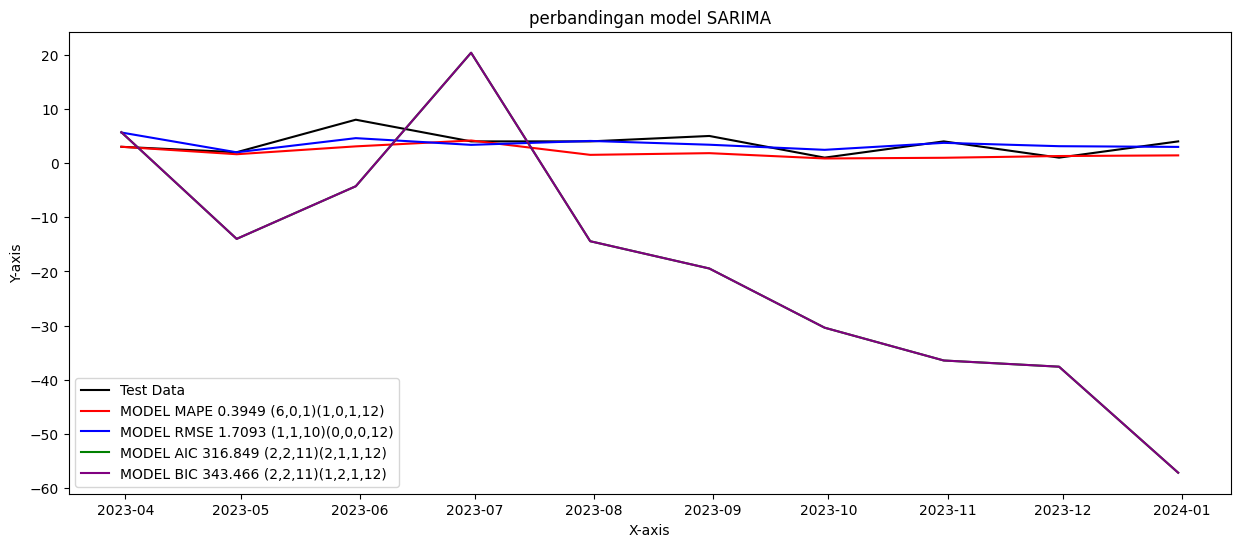

In [27]:
plt.figure(figsize=(15, 6))

plt.plot(test,color="black", label='Test Data')
plt.plot(prediksi_model_mape, color='red', label='MODEL MAPE 0.3949 (6,0,1)(1,0,1,12)')
plt.plot(prediksi_model_rmse, color='blue', label='MODEL RMSE 1.7093 (1,1,10)(0,0,0,12)')
plt.plot(prediksi_model_aic, color='green', label='MODEL AIC 316.849 (2,2,11)(2,1,1,12)')
plt.plot(prediksi_model_bic, color='purple', label='MODEL BIC 343.466 (2,2,11)(1,2,1,12)')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('perbandingan model SARIMA')

# Add legend
plt.legend()

# Display the plot
plt.show()

In [28]:
model_info.to_excel("hasil_sarimas.xlsx")